In [35]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fahadullaha/facial-emotion-recognition-dataset")

print("Path to dataset files:", path)

In [50]:
path = "./dataset"
DATASET_PATH = path + "/processed_data"
IMG_SIZE = 48
BATCH_SIZE = 32
NUM_CLASSES = 7

In [51]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode="grayscale",
    label_mode='categorical'
)

# test dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
        seed=42,                 # Same seed — same split guarantee
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    label_mode='categorical'

)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 49779 files belonging to 7 classes.
Using 39824 files for training.
Found 49779 files belonging to 7 classes.
Using 9955 files for validation.
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [38]:
# normalization layer, convert all train data to same scale 0 to 1
normalization_layer = tf.keras.layers.Rescaling(1./255)

# augmentation layer
augmentation_layer = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

# Apply to datasets
train_ds = train_ds.map(lambda x, y: (augmentation_layer(x, training=True), y))
val_ds   = val_ds  # val এ কিছুই করতে হবে না!


# Performance optimization — M5 Pro তে এটা জরুরি
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)



In [39]:
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.regularizers import l2

# CNN model
model = tf.keras.Sequential([
        # Normalize first layer হিসেবে
    tf.keras.layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 1)),


    # block 1
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 1), kernel_regularizer=l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), padding="same", activation="relu", kernel_regularizer=l2(0.001)),
    tf.keras.layers.MaxPooling2D(), # 48/2 = 24X24Xfilter(32)
    tf.keras.layers.Dropout(0.3),

    # block 2 -- input 24X24X32
    tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu" , kernel_regularizer=l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), padding="same", activation="relu", kernel_regularizer=l2(0.001)),
    tf.keras.layers.MaxPooling2D(), # 24/2 = 12
    tf.keras.layers.Dropout(0.3),
    # output = 12X12X64

    # block 3
    tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu", kernel_regularizer=l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3,3), padding="same", activation="relu",kernel_regularizer=l2(0.001)),
    tf.keras.layers.MaxPooling2D(), # 12/2 = 6
    tf.keras.layers.Dropout(0.5),
    # output = 6X6X128

    # classifier
    tf.keras.layers.Flatten(), # 6X6X128 = 4608 values
    tf.keras.layers.Dense(256, activation='relu'), # output=inputXoutput+bias = 4608X256+256=1,179,904

    tf.keras.layers.BatchNormalization(),
    #BatchNormalization প্রতিটা feature এর জন্য 4টা value রাখে:
        # γ (gamma)   → 256  ← learnable (scale)
        # β (beta)    → 256  ← learnable (shift)
        # μ (mean)    → 256  ← non-learnable (running stats)
        # σ (variance)→ 256  ← non-learnable (running stats)
    # 256 X4 = 1024 output for this block


    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
    # input × output + bias
    # 256 X 7 + 7 (7 is NUM_CLASSES)
    # = 1799
])


model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
        metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]

)



model.summary()


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,470,055 (5.61 MB)

 Trainable params: 1,469,095 (5.60 MB)

 Non-trainable params: 960 (3.75 KB)

In [40]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
)

Epoch 1/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - accuracy: 0.2351 - loss: 2.4397 - precision: 0.2723 - recall: 0.0518 - val_accuracy: 0.3486 - val_loss: 1.8558 - val_precision: 0.6956 - val_recall: 0.1359
Epoch 2/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.3607 - loss: 1.8071 - precision: 0.6281 - recall: 0.1269 - val_accuracy: 0.4555 - val_loss: 1.5882 - val_precision: 0.7095 - val_recall: 0.2118
Epoch 3/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 39s 31ms/step - accuracy: 0.4264 - loss: 1.6396 - precision: 0.6730 - recall: 0.1990 - val_accuracy: 0.4346 - val_loss: 1.6080 - val_precision: 0.5942 - val_recall: 0.3065
Epoch 4/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.4562 - loss: 1.5791 - precision: 0.6860 - recall: 0.2329 - val_accuracy: 0.5034 - val_loss: 1.4482 - val_precision: 0.7190 - val_recall: 0.3130
Epoch 5/30
1245/1245 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.4766 - loss: 1.5270 - precision: 0.7015 - recall: 0.2586 - val_accuracy: 0

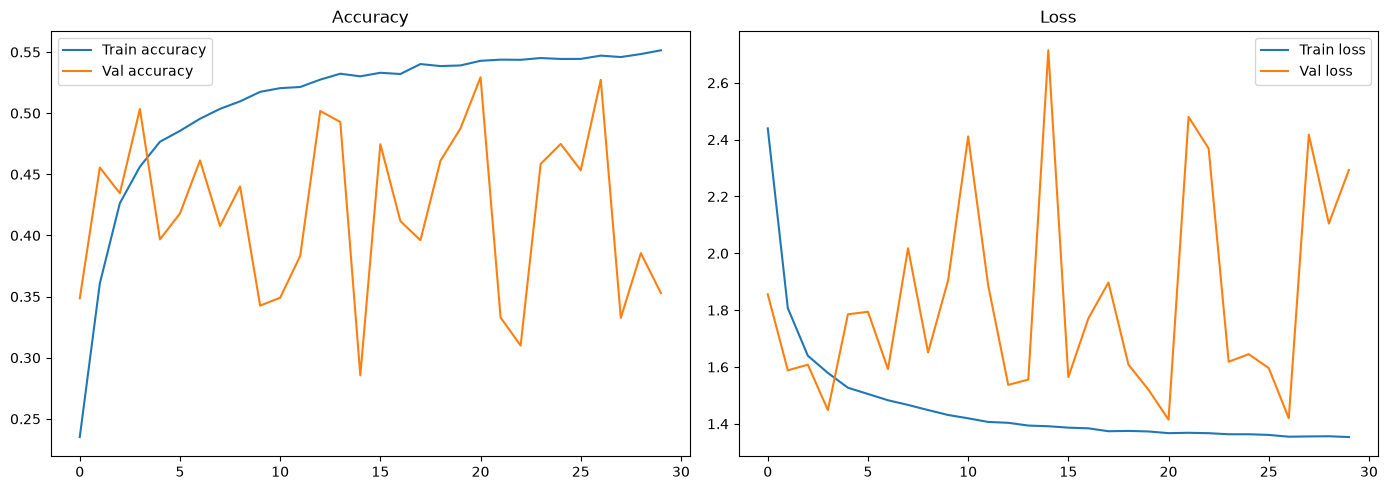

✅ Training done! Model saved to: ./dataset/processed_data


In [41]:
# ============================================
# 5. PLOT TRAINING HISTORY
# ============================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train accuracy')
ax1.plot(history.history['val_accuracy'], label='Val accuracy')
ax1.set_title('Accuracy')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train loss')
ax2.plot(history.history['val_loss'], label='Val loss')
ax2.set_title('Loss')
ax2.legend()

plt.tight_layout()
plt.savefig('training_history.png')
plt.show()
print("✅ Training done! Model saved to:", DATASET_PATH)
